# Skill Gap Agent v2 — Robust Architecture

## What's fixed vs v1

| Problem | Root Cause in v1 | Fix in v2 |
|---|---|---|
| Java flagged as gap despite being in resume | Gap analysis used hardcoded synonym rules in prompt; missed skills listed under languages section | New `skill_expander_node` + `gap_validator_node` — dynamic, LLM-driven, two-pass |
| Hallucinated / broken resource URLs | Roadmap prompt showed hardcoded example URLs which the LLM mirrored | New `resource_fetcher_node` — Tavily web search for real URLs before roadmap generation |
| GitHub≠Git treated as separate (and many similar) | Synonym rules were hardcoded strings in prompt | `skill_expander_node` uses LLM's knowledge of skill taxonomy — no hardcoded rules |

## New Pipeline
```
loader → analyzer → skill_expander → matcher → gap_analyzer → gap_validator → resource_fetcher → roadmap_generator
```

### Key Design Principle: "Skeptical AI"
Rather than trusting a single LLM call, we use multiple passes:
- Pass 1 (gap_analysis): identify candidate gaps
- Pass 2 (gap_validator): challenge each gap — "is this REALLY absent?"
This pattern dramatically reduces false positives.

In [ ]:
# %pip install langchain-groq langchain-community langchain-mongodb langgraph pymongo tavily-python pypdf

In [1]:
import os
from typing import List, Optional, Dict, TypedDict
from collections import Counter

from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import OllamaEmbeddings
from langchain_mongodb import MongoDBAtlasVectorSearch
from pymongo import MongoClient
from langgraph.graph import StateGraph, END

load_dotenv()

c:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

## Pydantic Schema Definitions

Two new schemas:
- `ExpandedSkillSet` — captures both explicit skills and dynamically inferred implied skills
- `ValidatedGap` — output of the second-pass gap validator

In [2]:
# ─────────────────────────────────────────────
#  Resume Analysis Models
# ─────────────────────────────────────────────
class SkillContext(BaseModel):
    name: str = Field(description="Normalized skill name (e.g., Python, MongoDB)")
    context: str = Field(description="Specific usage context from the resume")
    level: str = Field(description="Inferred level: Beginner, Intermediate, or Advanced")


class ResumeProfile(BaseModel):
    summary: str = Field(
        description="A 2-sentence professional summary optimized for vector similarity search, "
                    "naming the exact tech stack, experience type, and target domain."
    )
    skills: List[SkillContext] = Field(description="All technical skills with usage context and level.")
    target_roles: List[str] = Field(description="Inferred job titles the candidate is qualified for.")
    seniority_level: str = Field(
        description="Inferred seniority: Intern, Junior, Mid-level, Senior, Lead."
    )


# ─────────────────────────────────────────────
#  Expanded Skill Set Model
#  Captures BOTH explicit and dynamically inferred implied skills.
#  No hardcoded synonym rules — the LLM uses its taxonomy knowledge.
# ─────────────────────────────────────────────
class ImpliedSkill(BaseModel):
    name: str = Field(description="The implied skill name (normalized)")
    inferred_from: str = Field(description="The explicit skill that implies this knowledge")
    reasoning: str = Field(
        description="One sentence: why knowing X implies knowing Y "
                    "(e.g. 'GitHub requires Git commands to operate')"
    )


class ExpandedSkillSet(BaseModel):
    all_skills: List[str] = Field(
        description="Flat list of ALL skill names the candidate effectively has: "
                    "explicit from resume + high-confidence implied. Used for gap checking."
    )
    implied_skills: List[ImpliedSkill] = Field(
        description="Only the inferred skills with their reasoning (for transparency/logging)."
    )


# ─────────────────────────────────────────────
#  Gap Analysis Models
# ─────────────────────────────────────────────
class SkillGap(BaseModel):
    missing_skill: str = Field(description="Canonical name of the skill the candidate lacks.")
    frequency: int = Field(description="Number of matched job postings that require this skill.")
    importance: str = Field(
        description="'Critical' if core requirement in most jobs, 'Competitive Edge' if specialized."
    )


class GapAnalysisResult(BaseModel):
    critical_gaps: List[SkillGap]
    nice_to_haves: List[SkillGap]


# ─────────────────────────────────────────────
#  Validated Gap Model
#  Output of the second-pass validator node.
#  Each gap is challenged: is this TRULY absent?
# ─────────────────────────────────────────────
class ValidatedGap(BaseModel):
    skill: str = Field(description="Skill name being validated")
    is_true_gap: bool = Field(
        description="True only if the candidate genuinely lacks this competency "
                    "across ALL their explicit AND implied skills."
    )
    reasoning: str = Field(
        description="Explanation: why it IS a gap OR why it was marked as false positive."
    )


class ValidatedGapList(BaseModel):
    gaps: List[ValidatedGap]


# ─────────────────────────────────────────────
#  Roadmap Models
# ─────────────────────────────────────────────
class LearningResource(BaseModel):
    title: str
    url: str
    resource_type: str = Field(description="Course, Documentation, Practice, Video, Book")
    is_free: bool


class WeeklyTask(BaseModel):
    week_label: str
    topic: str
    tasks: List[str] = Field(description="3-5 specific, actionable tasks")
    milestone: str = Field(description="Concrete GitHub-pushable deliverable by week end")


class LearningStep(BaseModel):
    skill: str
    importance: str
    why_it_matters: str
    leverage_from_background: str
    time_estimate: str
    resources: List[LearningResource]
    weekly_breakdown: List[WeeklyTask]
    capstone_project: str
    resume_bullet: str


class RoadmapMeta(BaseModel):
    seniority_level: str
    total_timeline: str
    learning_sequence: List[str]
    market_outlook: str

## Agent State

Two new fields:
- `expanded_skills` — the dynamically expanded skill set
- `validated_gaps` — confirmed true gaps after the second-pass validator
- `skill_resources` — real URLs fetched from the web before roadmap generation

In [3]:
class AgentState(TypedDict):
    file_path: str
    resume_text: str
    profile: ResumeProfile
    expanded_skills: ExpandedSkillSet      
    matches: List[dict]
    gap_analysis: dict
    validated_gaps: List[dict]             
    skill_resources: Dict[str, List[dict]] 
    roadmap: dict
    error: Optional[str]

## Node Definitions

In [4]:
# ─────────────────────────────────────────────
#  Node 1: PDF Text Extraction
# ─────────────────────────────────────────────
def extract_text_node(state: AgentState) -> dict:
    """Loads and parses a PDF resume into plain text."""
    try:
        loader = PyPDFLoader(state["file_path"])
        docs = loader.load()
        if not docs:
            return {"error": "PDF Error: No pages found."}
        full_text = "\n".join(doc.page_content.strip() for doc in docs if doc.page_content.strip())
        return {"resume_text": full_text}
    except Exception as e:
        return {"error": f"PDF Error: {str(e)}"}

In [ ]:
# ─────────────────────────────────────────────
#  Node 2: Resume Analysis
#  explicitly extracts skills from project descriptions too,
#  not just the Skills section. 
# ─────────────────────────────────────────────
def analyze_resume_node(state: AgentState) -> dict:
    """Converts raw resume text into a structured ResumeProfile."""
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
    structured_llm = llm.with_structured_output(ResumeProfile)

    system_prompt = """
    You are an expert HR Data Scientist specializing in tech hiring. Analyze the resume text.

    EXTRACTION RULES — be exhaustive:
    1. Extract EVERY technical skill — from the Skills/Technical section AND from project
       descriptions AND from certification names.
    2. Treat the Skills/Technical section as ground truth — if a language is listed there,
       it is confirmed known regardless of project usage.
    3. Normalize names consistently: "ReactJS" → "React", "SpringBoot" → "Spring Boot",
       "Postgres" → "PostgreSQL", "node" → "Node.js"
    4. Infer level from project depth:
       - Beginner: mentioned once or in a minor role
       - Intermediate: used in 1-2 meaningful projects
       - Advanced: complex architecture, multiple projects, or explicit depth (JWT, security, etc.)
    5. Write a vector-search-optimized summary with exact frameworks, languages, and domains.
    6. Be generous with target_roles — list all titles the candidate could plausibly apply for.
    """

    try:
        profile = structured_llm.invoke([
            ("system", system_prompt),
            ("human", state["resume_text"])
        ])
        return {"profile": profile}
    except Exception as e:
        return {"error": f"Resume Analysis Error: {str(e)}"}

In [6]:
# ─────────────────────────────────────────────
#  Node 3: Skill Expander 
#
#  Problem it solves:
#  - Resume says "GitHub" → v1 didn't know this implies "Git"
#  - Resume says "Spring Boot" → v1 didn't know this confirms "Java"
#  - Resume says "React" → v1 didn't know this confirms "JavaScript"
#
#  How it works:
#  Instead of hardcoding any rules (brittle, misses many cases), we ask the LLM
#  to use its own knowledge of the software ecosystem to infer what skills are
#  NECESSARILY implied by the candidate's explicit skills.
#
#  This covers thousands of relationships without a single hardcoded rule:
#  GitHub→Git, Spring Boot→Java, React→JS, Docker→Linux CLI, JPA→SQL, etc.
# ─────────────────────────────────────────────
def skill_expander_node(state: AgentState) -> dict:
    """
    Dynamically infers the full skill set implied by explicit resume skills.
    Uses LLM's knowledge of tech taxonomy — no hardcoded rules.
    """
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
    structured_llm = llm.with_structured_output(ExpandedSkillSet)

    explicit_skills = [s.name for s in state["profile"].skills]

    system_prompt = """
    You are a Software Engineering Expert with deep knowledge of technology skill taxonomies.

    Given a developer's explicit skills, identify all skills that are NECESSARILY implied.

    INFERENCE CATEGORIES — only infer if relationship is near-certain:

    1. PREREQUISITE — cannot use X without knowing Y:
       - GitHub / GitLab / Bitbucket → Git (version control commands)
       - Any cloud platform (AWS/GCP/Azure) → Linux CLI, SSH basics
       - Kubernetes → Docker (K8s orchestrates Docker containers)
       - Any CI/CD pipeline → Git

    2. BUILT-ON — framework/library runs on a language:
       - Spring Boot / Spring MVC / Hibernate → Java
       - React / Next.js / Vue / Angular → JavaScript
       - Django / Flask / FastAPI → Python
       - Express.js / Node.js frameworks → JavaScript
       - Rails → Ruby
       - Laravel → PHP

    3. BUNDLED — technology always used with another:
       - JPA / Hibernate → SQL (ORM over relational DB)
       - Spring Security / JWT → Authentication/Authorization concepts
       - React → HTML, CSS (cannot build UI without them)
       - Any testing framework (JUnit, Jest, PyTest) → unit testing concepts
       - REST API development → HTTP protocol knowledge
       - Docker → Containerization, basic Linux
       - Solidity / Hardhat / Ethers.js → Blockchain / Smart Contract concepts

    4. SUPERSET — tool X is a superset of tool Y:
       - PostgreSQL / MySQL / Oracle → SQL, Relational Databases
       - MongoDB → NoSQL, Document databases
       - Tailwind CSS → CSS fundamentals
       - TypeScript → JavaScript (TS is a superset)

    RULES:
    - Only infer with HIGH confidence — relationship must be near-universal in the industry
    - Do NOT infer loosely related skills (e.g., Python → data science is NOT certain)
    - Do NOT duplicate: if Git is already explicit, don't re-add it as implied
    - The all_skills list = explicit skills + high-confidence implied (no duplicates)
    """

    human_msg = f"""
    Developer's explicit skills from resume:
    {', '.join(explicit_skills)}

    Expand to include all necessarily implied skills.
    Return the complete flat list in all_skills (explicit + implied, deduplicated).
    """

    try:
        expanded = structured_llm.invoke([
            ("system", system_prompt),
            ("human", human_msg)
        ])
        print(f"Skills expanded: {len(explicit_skills)} explicit → {len(expanded.all_skills)} total")
        if expanded.implied_skills:
            print("Implied skills inferred:")
            for s in expanded.implied_skills:
                print(f"  {s.inferred_from} → {s.name}: {s.reasoning}")
        return {"expanded_skills": expanded}
    except Exception as e:
        print(f"Skill expansion failed ({e}), using explicit skills only.")
        # Graceful fallback: use explicit skills as-is
        fallback = ExpandedSkillSet(
            all_skills=explicit_skills,
            implied_skills=[]
        )
        return {"expanded_skills": fallback}

In [7]:
# ─────────────────────────────────────────────
#  Node 4: MongoDB Atlas Vector Search
# ─────────────────────────────────────────────
def vector_search_node(state: AgentState) -> dict:
    """Finds the top-k most semantically similar job postings via Atlas Vector Search."""
    if state.get("error"):
        return {}

    try:
        embeddings = OllamaEmbeddings(model=os.getenv("MODEL_NAME", "qwen3-embedding:0.6b"))
        client = MongoClient(os.getenv("MONGO_URI"))
        collection = client[os.getenv("DB_NAME")][os.getenv("COLLECTION_NAME")]

        vector_store = MongoDBAtlasVectorSearch(
            collection=collection,
            embedding=embeddings,
            index_name="vector_index",
            text_key="job_description_summary",
            embedding_key="job_embedding"
        )

        results = vector_store.similarity_search_with_score(state["profile"].summary, k=5)

        job_matches = [
            {
                "title": doc.metadata.get("job_title"),
                "required_skills": doc.metadata.get("skills_required", []),
                "score": float(score),
                "url": doc.metadata.get("job_url")
            }
            for doc, score in results
        ]

        client.close()
        return {"matches": job_matches}

    except Exception as e:
        return {"error": f"Vector Search Error: {str(e)}"}

In [8]:
# ─────────────────────────────────────────────
#  Node 5: Gap Analysis
#  Now compares against EXPANDED skills (explicit + implied),
#  not just raw resume skills. This fixes the Java false-positive issue.
# ─────────────────────────────────────────────
def gap_analysis_node(state: AgentState) -> dict:
    """
    First-pass gap identification using the full expanded skill set.
    NOTE: This is followed by gap_validator_node for a second verification pass.
    """
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

    # ── KEY CHANGE: use EXPANDED skills, not just profile.skills ──
    all_candidate_skills = state["expanded_skills"].all_skills
    explicit_skills = [s.name for s in state["profile"].skills]
    implied_skill_names = [s.name for s in state["expanded_skills"].implied_skills]

    all_job_skills_raw: List[str] = []
    for match in state["matches"]:
        all_job_skills_raw.extend(match.get("required_skills", []))

    skill_frequency: Counter = Counter(all_job_skills_raw)
    total_jobs = len(state["matches"])

    market_requirements = [
        f"{skill} (appears in {count}/{total_jobs} matched jobs)"
        for skill, count in skill_frequency.most_common()
    ]

    system_prompt = """
    You are a Senior Technical Recruiter performing a precise skill gap analysis.

    CRITICAL RULES:
    1. The candidate's skill set has TWO layers:
       - EXPLICIT: directly stated in the resume — treat as confirmed
       - IMPLIED: logically inferred from explicit skills — treat as confirmed
       A skill covered by EITHER layer is NOT a gap.

    2. SEMANTIC MATCHING — don't flag a gap if covered under a different name:
       - "SQL" is covered if candidate has PostgreSQL, MySQL, or any RDBMS
       - "REST API" is covered if candidate has Spring Boot, Express, Flask, or similar
       - "Version control" is covered if candidate has Git or GitHub
       - "NoSQL" is covered if candidate has MongoDB
       - "Frontend" is covered if candidate has React, Vue, or Angular
       Think broadly about what competency is actually required.

    3. FREQUENCY-BASED CLASSIFICATION:
       - Critical: appears in ≥60% of matched jobs AND is a true, genuine gap
       - Competitive Edge: <60% frequency, or advanced specialization

    4. EXCLUDE: soft skills, communication, teamwork, adaptability — hard technical only.

    5. CONSERVATIVE: when in doubt whether something is a gap, do NOT include it.
       It is better to miss a minor gap than to falsely flag something the candidate knows.
    """

    human_msg = f"""
    CANDIDATE — EXPLICIT SKILLS (directly from resume):
    {', '.join(explicit_skills)}

    CANDIDATE — IMPLIED SKILLS (necessarily inferred from explicit):
    {', '.join(implied_skill_names) if implied_skill_names else 'None additional'}

    CANDIDATE — COMPLETE EFFECTIVE SKILL SET (use THIS for gap checking):
    {', '.join(all_candidate_skills)}

    MARKET REQUIREMENTS (across {total_jobs} matched jobs):
    {chr(10).join(market_requirements)}

    Identify gaps that are truly absent from the complete effective skill set.
    """

    try:
        structured_llm = llm.with_structured_output(GapAnalysisResult)
        gap_result: GapAnalysisResult = structured_llm.invoke([
            ("system", system_prompt),
            ("human", human_msg)
        ])
        return {"gap_analysis": gap_result.dict()}
    except Exception as e:
        return {"error": f"Gap Analysis Error: {str(e)}"}

In [9]:
# ─────────────────────────────────────────────
#  Node 6: Gap Validator 
#
#  Problem it solves:
#  Even with expanded skills, LLMs can still occasionally flag false positives
#  (e.g., flagging "Java" when Spring Boot is listed, or "SQL" when JPA is listed).
#  This node is a dedicated "skeptic" — it challenges every proposed gap.
#
#  Pattern: "Skeptical AI" — two-pass validation
#  Pass 1 (gap_analysis): "What might be missing?"
#  Pass 2 (gap_validator): "Are you SURE each of these is actually missing?"
#
#  The validator also has access to raw resume text for project-level evidence.
# ─────────────────────────────────────────────
def gap_validator_node(state: AgentState) -> dict:
    """
    Second-pass verification of identified gaps.
    Challenges each gap against the full expanded skill set AND project evidence.
    Removes false positives before roadmap generation.
    """
    if state.get("error"):
        return {}

    gap_analysis = state["gap_analysis"]
    all_proposed_gaps = (
        gap_analysis.get("critical_gaps", []) +
        gap_analysis.get("nice_to_haves", [])
    )

    if not all_proposed_gaps:
        print("No gaps proposed — candidate is well-matched!")
        return {"validated_gaps": []}

    # Build a lookup for importance/frequency from original analysis
    importance_map = {
        g["missing_skill"]: ("Critical", g["frequency"])
        for g in gap_analysis.get("critical_gaps", [])
    }
    importance_map.update({
        g["missing_skill"]: ("Competitive Edge", g["frequency"])
        for g in gap_analysis.get("nice_to_haves", [])
    })

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
    structured_llm = llm.with_structured_output(ValidatedGapList)

    all_candidate_skills = state["expanded_skills"].all_skills
    # Use first 2000 chars of resume for project evidence
    resume_excerpt = state["resume_text"][:2500]

    gaps_to_check = [
        f"- {g['missing_skill']} (classified as {importance_map.get(g['missing_skill'], ('?', 0))[0]})"
        for g in all_proposed_gaps
    ]

    system_prompt = """
    You are a quality auditor catching FALSE POSITIVES in a skill gap analysis.
    Your job is to be SKEPTICAL — only confirm a gap if you are highly confident.

    For each proposed gap skill, apply this verification checklist:

    ❌ Mark as FALSE POSITIVE (is_true_gap=False) if ANY of these are true:
    □ The exact skill or a direct synonym appears in the candidate's skill set
    □ The candidate has a technology that REQUIRES this skill as a prerequisite
       (e.g., Spring Boot user definitely knows Java; GitHub user definitely knows Git)
    □ The candidate has a higher-level framework that INCLUDES this skill
       (e.g., PostgreSQL user definitely knows SQL; React developer definitely knows JavaScript)
    □ The candidate's project descriptions DEMONSTRATE this competency
       (e.g., built REST APIs → knows REST; used JWT → knows auth concepts)
    □ The skill is just a renamed/rebranded version of something they have
       (e.g., "Relational Databases" when they have MySQL)

    ✅ Mark as TRUE GAP (is_true_gap=True) ONLY if:
    □ The skill is not present in any form in the candidate's explicit OR implied skills
    □ None of their technologies imply this skill
    □ Their project descriptions don't demonstrate this competency

    Always provide clear reasoning for your decision.
    """

    human_msg = f"""
    CANDIDATE'S COMPLETE EFFECTIVE SKILL SET:
    {', '.join(all_candidate_skills)}

    CANDIDATE'S PROJECT EXPERIENCE (excerpt):
    {resume_excerpt}

    PROPOSED GAPS TO VERIFY:
    {chr(10).join(gaps_to_check)}

    For each proposed gap, determine: is this skill truly absent given ALL the evidence above?
    """

    try:
        validated: ValidatedGapList = structured_llm.invoke([
            ("system", system_prompt),
            ("human", human_msg)
        ])

        # Build validated_gaps list with original importance/frequency attached
        confirmed_gaps = []
        removed_gaps = []

        for v in validated.gaps:
            if v.is_true_gap:
                importance, frequency = importance_map.get(v.skill, ("Competitive Edge", 1))
                confirmed_gaps.append({
                    "skill": v.skill,
                    "importance": importance,
                    "frequency": frequency,
                    "validation_reason": v.reasoning
                })
            else:
                removed_gaps.append(f"{v.skill} → {v.reasoning}")

        # Logging for transparency
        print(f"\nGap Validation Results:")
        print(f"  Proposed: {len(all_proposed_gaps)} gaps")
        print(f"  Confirmed: {len(confirmed_gaps)} true gaps")
        if removed_gaps:
            print(f"  Removed (false positives):")
            for r in removed_gaps:
                print(f"    ✗ {r}")
        print(f"  Confirmed gaps: {[g['skill'] for g in confirmed_gaps]}")

        return {"validated_gaps": confirmed_gaps}

    except Exception as e:
        print(f"Validator failed ({e}), using original gaps as fallback.")
        # Fallback: pass through all original gaps
        fallback_gaps = [
            {"skill": g["missing_skill"], "importance": "Critical", "frequency": g["frequency"]}
            for g in gap_analysis.get("critical_gaps", [])
        ] + [
            {"skill": g["missing_skill"], "importance": "Competitive Edge", "frequency": g["frequency"]}
            for g in gap_analysis.get("nice_to_haves", [])
        ]
        return {"validated_gaps": fallback_gaps}

In [10]:
# ─────────────────────────────────────────────
#  Node 7: Resource Fetcher 
#
#  Problem it solves:
#  v1 prompted the LLM with hardcoded example URLs like:
#    "SQL → SQLBolt (https://sqlbolt.com)"
#    "CI/CD → GitHub Actions Docs"
#  The LLM then mirrored these patterns and generated plausible-but-wrong URLs.
#
#  Fix:
#  1. For each confirmed gap, run live web searches for real current resources
#  2. Pass those REAL URLs to the LLM for curation (not generation)
#  3. The LLM only selects and describes — never invents a URL
#
#  Uses Tavily (preferred) with DuckDuckGo as fallback.
# ─────────────────────────────────────────────
def resource_fetcher_node(state: AgentState) -> dict:
    """
    Fetches REAL, current learning resources via web search for each confirmed gap skill.
    The LLM curates (selects + describes) from real search results — it never invents URLs.
    """
    if state.get("error"):
        return {}

    validated_gaps = state["validated_gaps"]
    if not validated_gaps:
        return {"skill_resources": {}}

    # ── Set up search tool (Tavily preferred, DuckDuckGo fallback) ──
    search_tool = None
    search_backend = "none"
    try:
        from langchain_community.tools.tavily_search import TavilySearchResults
        if os.getenv("TAVILY_API_KEY"):
            search_tool = TavilySearchResults(max_results=6, search_depth="basic")
            search_backend = "tavily"
    except ImportError:
        pass

    if search_tool is None:
        try:
            from langchain_community.tools import DuckDuckGoSearchRun
            search_tool = DuckDuckGoSearchRun()
            search_backend = "duckduckgo"
        except ImportError:
            pass

    print(f"Resource fetcher using: {search_backend}")

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

    class ResourceList(BaseModel):
        resources: List[LearningResource] = Field(
            description="2-4 curated resources — ONLY use URLs present in the search results provided."
        )

    structured_llm = llm.with_structured_output(ResourceList)
    skill_resources: Dict[str, List[dict]] = {}

    for gap in validated_gaps:
        skill = gap["skill"]
        raw_results = []

        if search_tool is not None:
            # Search for free tutorials + official docs separately for better coverage
            queries = [
                f"{skill} free tutorial beginner 2024",
                f"{skill} official documentation",
            ]
            for query in queries:
                try:
                    results = search_tool.invoke(query)
                    if isinstance(results, list):
                        raw_results.extend(results)
                    elif isinstance(results, str):
                        # DuckDuckGo returns a string
                        raw_results.append({"content": results, "url": "", "title": query})
                except Exception as e:
                    print(f"  Search failed for '{query}': {e}")

        if raw_results:
            # Format results for the LLM curator
            results_text = "\n".join([
                f"Title: {r.get('title', 'Unknown')}\n"
                f"URL: {r.get('url', r.get('href', ''))}\n"
                f"Snippet: {str(r.get('content', r.get('snippet', '')))[:300]}"
                for r in raw_results if isinstance(r, dict)
            ])

            curation_prompt = f"""
            Select 2-4 best learning resources for: {skill}

            SEARCH RESULTS (these are REAL, verified URLs):
            {results_text}

            SELECTION CRITERIA (in priority order):
            1. Official documentation (most authoritative)
            2. Interactive platforms (freeCodeCamp, Codecademy, Exercism)
            3. Reputable courses (Udemy, Coursera, Pluralsight)
            4. High-quality YouTube channels (official channels only)

            STRICT RULE: Only use URLs from the search results above.
            Do NOT invent, modify, or guess at URLs.
            If a result looks like official documentation, mark is_free=True.
            """

            try:
                result = structured_llm.invoke([
                    ("system", "You are curating learning resources. ONLY use URLs from the provided search results. Never invent URLs."),
                    ("human", curation_prompt)
                ])
                skill_resources[skill] = [r.dict() for r in result.resources]
                print(f"  ✓ {skill}: found {len(skill_resources[skill])} resources")
            except Exception as e:
                print(f"  ✗ {skill}: curation failed ({e}), roadmap will use LLM knowledge")
                skill_resources[skill] = []
        else:
            print(f"  ~ {skill}: no search results, roadmap will use LLM knowledge")
            skill_resources[skill] = []

    return {"skill_resources": skill_resources}

In [11]:
# ─────────────────────────────────────────────
#  Node 8: Roadmap Generator
#  1. Uses validated_gaps (not raw gap_analysis) → no false positives
#  2. Injects real resources from resource_fetcher → no hallucinated URLs
#  3. Prompt no longer shows hardcoded example URLs
#  4. Capstone is explicitly grounded in candidate's actual projects
# ─────────────────────────────────────────────
def roadmap_generator_node(state: AgentState) -> dict:
    """
    Generates a personalized roadmap using VALIDATED gaps and REAL resources.
    One LLM call per skill (prevents truncation); final metadata call assembles the whole.
    """
    if state.get("error"):
        return {}

    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.2)
    profile: ResumeProfile = state["profile"]
    validated_gaps: List[dict] = state["validated_gaps"]
    skill_resources: Dict[str, List[dict]] = state.get("skill_resources", {})

    # Handle no-gap case
    if not validated_gaps:
        return {"roadmap": {
            "seniority_level": profile.seniority_level,
            "total_timeline": "0 weeks — no critical gaps found",
            "learning_sequence": [],
            "action_plan": [],
            "market_outlook": (
                "Excellent news! Your skill set is well-aligned with current market requirements. "
                "Focus on deepening expertise in your strongest areas and building portfolio projects."
            )
        }}

    # ── Sort: critical first (by frequency desc), then top 3 competitive edge ──
    critical = sorted(
        [g for g in validated_gaps if g["importance"] == "Critical"],
        key=lambda x: x["frequency"], reverse=True
    )
    competitive = [g for g in validated_gaps if g["importance"] != "Critical"][:3]
    skills_to_learn = critical + competitive

    existing_skills = ", ".join(f"{s.name} ({s.level})" for s in profile.skills)
    target_roles = ", ".join(profile.target_roles)

    # Extract actual project names from resume for personalized capstone
    resume_excerpt = state["resume_text"][:1500]

    step_system_prompt = f"""
    You are a world-class Software Engineering Mentor. Generate a single LearningStep for ONE skill.

    CANDIDATE CONTEXT:
    - Seniority: {profile.seniority_level}
    - Target Roles: {target_roles}
    - Existing Skills: {existing_skills}
    - Their Projects (from resume):
    {resume_excerpt}

    QUALITY RULES — the roadmap must be specific and actionable:

    RESOURCES:
    - Real resources will be provided in the prompt — USE those exact URLs and titles
    - If no real resources are provided, name SPECIFIC well-known resources
      (e.g., 'Kubernetes.io official docs', 'TechWorld with Nana on YouTube')
    - NEVER invent URLs or use vague descriptions like 'Official X Tutorial'

    WEEKLY TASKS:
    - Each task must be specific: 'Complete Chapters 1-4 of X' not 'Learn X basics'
    - Each week ends with a concrete GitHub-pushable MILESTONE
    - 3-5 tasks per week

    CAPSTONE:
    - Must integrate with ONE of the candidate's ACTUAL existing projects from their resume
    - Name the specific project (e.g., 'Add Kafka event streaming to the RydeApplication backend')
    - Not a generic hello-world project

    RESUME BULLET:
    - Action verb + metric + specific project reference
    - Example: 'Refactored RydeApplication to event-driven architecture using Kafka, 
      reducing booking latency by ~40%'
    """

    step_llm = llm.with_structured_output(LearningStep)
    action_plan: List[dict] = []

    for i, gap in enumerate(skills_to_learn):
        skill = gap["skill"]
        real_resources = skill_resources.get(skill, [])

        # Build the resources section of the prompt
        if real_resources:
            resources_block = "\n    VERIFIED REAL RESOURCES (use these exact titles and URLs):\n"
            for r in real_resources:
                tag = "FREE" if r.get("is_free") else "PAID"
                resources_block += f"    [{tag}] {r['title']} → {r['url']} ({r.get('resource_type', 'Resource')})\n"
        else:
            resources_block = "\n    No pre-fetched resources — name specific, well-known resources.\n"

        human_msg = f"""
    Generate a complete LearningStep for:

    Skill:      {skill}
    Importance: {gap['importance']} (needed in {gap['frequency']} matched jobs)
    Priority:   #{i + 1} in learning sequence
    {resources_block}

    Make the capstone project specific to this candidate's existing work.
    Make the weekly tasks concrete and measurable.
        """

        try:
            step: LearningStep = step_llm.invoke([
                ("system", step_system_prompt),
                ("human", human_msg)
            ])
            step_dict = step.dict()

            # If we have real resources, override LLM-generated ones
            if real_resources:
                step_dict["resources"] = real_resources

            action_plan.append(step_dict)
            print(f"[{i+1}/{len(skills_to_learn)}] ✓ Generated roadmap for: {skill}")
        except Exception as e:
            print(f"[{i+1}/{len(skills_to_learn)}] ✗ Skipped {skill}: {e}")
            action_plan.append({
                "skill": skill, "importance": gap["importance"],
                "why_it_matters": "Could not generate — please retry.",
                "leverage_from_background": "",
                "time_estimate": "TBD",
                "resources": real_resources,
                "weekly_breakdown": [],
                "capstone_project": "",
                "resume_bullet": ""
            })

    # ── Generate roadmap metadata ──
    meta_llm = llm.with_structured_output(RoadmapMeta)
    skill_names = [g["skill"] for g in skills_to_learn]
    time_estimates = [
        s.get("time_estimate", "") for s in action_plan
        if s.get("time_estimate") and s["time_estimate"] != "TBD"
    ]

    try:
        meta: RoadmapMeta = meta_llm.invoke([
            ("system", "You are a Senior Engineering Career Coach. Be concise and realistic."),
            ("human", f"""
    Candidate: {profile.seniority_level} targeting {target_roles}.
    Skills to learn (in order proposed): {skill_names}
    Individual time estimates: {time_estimates}

    Provide:
    1. seniority_level — match what the resume implies
    2. total_timeline — realistic sum (add ~20% buffer for review/rest)
    3. learning_sequence — reorder with prerequisites first:
       (e.g., SQL before ORMs, Git before CI/CD, Docker before Kubernetes)
    4. market_outlook — 2-3 specific sentences on why these gaps matter for {target_roles}
            """)
        ])
    except Exception as e:
        print(f"Metadata generation failed ({e}), using defaults.")
        meta = RoadmapMeta(
            seniority_level=profile.seniority_level,
            total_timeline="See individual skill estimates",
            learning_sequence=skill_names,
            market_outlook="Bridging these gaps will significantly improve candidacy for target roles."
        )

    return {"roadmap": {
        "seniority_level":   meta.seniority_level,
        "total_timeline":    meta.total_timeline,
        "learning_sequence": meta.learning_sequence,
        "action_plan":       action_plan,
        "market_outlook":    meta.market_outlook
    }}

## Graph Assembly

New pipeline:
```
loader → analyzer → skill_expander → matcher → gap_analyzer → gap_validator → resource_fetcher → roadmap_generator
```

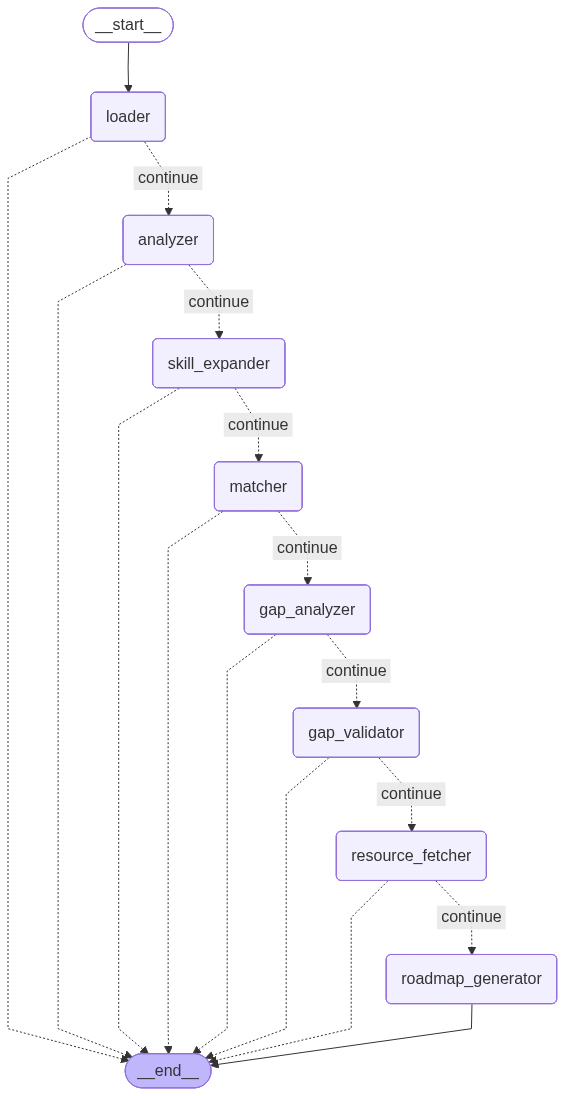

In [ ]:
from IPython.display import Image, display

def should_continue(state: AgentState) -> str:
    return END if state.get("error") else "continue"


workflow = StateGraph(AgentState)

# Register all nodes
workflow.add_node("loader",            extract_text_node)
workflow.add_node("analyzer",          analyze_resume_node)
workflow.add_node("skill_expander",    skill_expander_node)    
workflow.add_node("matcher",           vector_search_node)
workflow.add_node("gap_analyzer",      gap_analysis_node)
workflow.add_node("gap_validator",     gap_validator_node)    
workflow.add_node("resource_fetcher",  resource_fetcher_node) 
workflow.add_node("roadmap_generator", roadmap_generator_node)

workflow.set_entry_point("loader")

# Error-guarded edges
for src, dst in [
    ("loader",           "analyzer"),
    ("analyzer",         "skill_expander"),
    ("skill_expander",   "matcher"),
    ("matcher",          "gap_analyzer"),
    ("gap_analyzer",     "gap_validator"),
    ("gap_validator",    "resource_fetcher"),
    ("resource_fetcher", "roadmap_generator"),
]:
    workflow.add_conditional_edges(
        src,
        should_continue,
        {"continue": dst, END: END}
    )

workflow.add_edge("roadmap_generator", END)

app = workflow.compile()

image = app.get_graph().draw_mermaid_png()
display(Image(image))

In [ ]:
# Run the pipeline
final_state = app.invoke({"file_path": "./Resume-SM.pdf"})

if final_state.get("error"):
    print(f"Pipeline failed: {final_state['error']}")
else:
    print("Pipeline completed successfully.")
    
    # Show what was inferred
    expanded = final_state.get("expanded_skills")
    if expanded:
        print(f"\nSkill expansion summary:")
        print(f"  Explicit: {len(final_state['profile'].skills)} skills")
        print(f"  After expansion: {len(expanded.all_skills)} skills")
        if expanded.implied_skills:
            print(f"  Key inferences:")
            for s in expanded.implied_skills[:5]:
                print(f"    {s.inferred_from} → {s.name}")

In [ ]:
import textwrap

def print_roadmap(state: AgentState) -> None:
    roadmap = state.get("roadmap", {})
    if not roadmap:
        print("No roadmap available.")
        return

    print("=" * 70)
    print(f"  PERSONALIZED CAREER ROADMAP")
    print(f"  Seniority: {roadmap.get('seniority_level')}")
    print(f"  Total Timeline: {roadmap.get('total_timeline')}")
    print("=" * 70)
    print(f"\n📊 MARKET OUTLOOK\n{roadmap.get('market_outlook')}")

    print(f"\n🔢 RECOMMENDED LEARNING SEQUENCE:")
    for i, skill in enumerate(roadmap.get("learning_sequence", []), 1):
        print(f"   {i}. {skill}")

    for step in roadmap.get("action_plan", []):
        badge = "🔴 CRITICAL" if step["importance"] == "Critical" else "🟡 COMPETITIVE EDGE"
        print(f"\n{'─' * 70}")
        print(f"  {badge}  |  {step['skill'].upper()}  |  {step['time_estimate']}")
        print(f"{'─' * 70}")
        print(f"\n📌 Why it matters:\n   {step['why_it_matters']}")
        print(f"\n⚡ Leverage from your background:\n   {step['leverage_from_background']}")

        print(f"\n📚 RESOURCES:")
        for r in step.get("resources", []):
            free_tag = "[FREE]" if r.get("is_free") else "[PAID]"
            print(f"   {free_tag} {r['title']}")
            print(f"         → {r['url']}  ({r.get('resource_type', '')})")

        print(f"\n📅 WEEK-BY-WEEK PLAN:")
        for week in step.get("weekly_breakdown", []):
            print(f"\n   [{week['week_label']}] — {week['topic']}")
            for task in week.get("tasks", []):
                print(f"     • {task}")
            print(f"     ✅ Milestone: {week['milestone']}")

        print(f"\n🚀 CAPSTONE PROJECT:")
        print(textwrap.fill(f"   {step['capstone_project']}", width=68, subsequent_indent="   "))

        print(f"\n📝 RESUME BULLET:")
        print(textwrap.fill(f"   {step['resume_bullet']}", width=68, subsequent_indent="   "))

    print(f"\n{'=' * 70}")


print_roadmap(final_state)

In [ ]:
import pprint

def print_agent_state(state: AgentState) -> None:
    print("=" * 70)
    print("AGENT STATE SUMMARY")
    print("=" * 70)
    print(f"File Path: {state.get('file_path')}")
    print(f"Resume Text Length: {len(state.get('resume_text', ''))}")
    if state.get('profile'):
        print(f"Profile Skills: {len(state['profile'].skills)}")
        print(f"Target Roles: {state['profile'].target_roles}")
    if state.get('expanded_skills'):
        print(f"Expanded Skills: {len(state['expanded_skills'].all_skills)}")
    print(f"Matches: {len(state.get('matches', []))}")
    if state.get('gap_analysis'):
        critical = len(state['gap_analysis'].get('critical_gaps', []))
        nice = len(state['gap_analysis'].get('nice_to_haves', []))
        print(f"Gaps: {critical} critical, {nice} nice-to-have")
    print(f"Validated Gaps: {len(state.get('validated_gaps', []))}")
    print(f"Skill Resources: {len(state.get('skill_resources', {}))}")
    if state.get('roadmap'):
        print(f"Roadmap Skills: {len(state['roadmap'].get('action_plan', []))}")
    if state.get('error'):
        print(f"Error: {state['error']}")
    print("=" * 70)

print_agent_state(final_state)